# Live Anomaly Detector - Comprehensive Testing

This notebook tests the trained anomaly detection model against all possible fault types:
- **4 Single Anomalies:** CPU, Memory, Disk, Network
- **6 Compound Anomalies:** All combinations of 2 simultaneous faults

The test runs each anomaly type for 20 seconds with 10-second baseline periods in between, then provides comprehensive performance analysis and visualizations.

## 1. Setup & Configuration

In [26]:
import sys
import pickle
import time
import threading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import your current code (functions)
# Adjust this path so it points to where your monitor.py and injector.py live
sys.path.append("..")

from src.monitor import collect_sample
from src.injector import create_payload_pool, run_exfiltration

import warnings

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

print("Imports successful")

Imports successful


In [27]:
RUN_ID = "20260307_163847"  # the run used to train the saved model/scaler/features

MODEL_PATH = "../models/best_model_" + RUN_ID + ".pkl"
SCALER_PATH = "../models/scaler_" + RUN_ID + ".pkl"
FEATURES_PATH = "../models/feature_cols_" + RUN_ID + ".pkl"

# Live test parameters
BASELINE_DURATION = 20  # seconds
INJECTION_DURATION = 60  # seconds (match your realistic anomaly window)
SAMPLING_INTERVAL_S = 1.0

# VM receiver target (must match your controller/injector usage)
RECEIVER_HOST = "172.20.10.7"
RECEIVER_PORT = 5001

# Exfil settings (MB/s)
EXFIL_RATE_MBPS = 40.0
PAYLOAD_SIZE_MB = 800
PAYLOAD_COUNT = 5

print("Run ID:", RUN_ID)
print("Baseline duration:", BASELINE_DURATION, "seconds")
print("Injection duration:", INJECTION_DURATION, "seconds")

Run ID: 20260307_163847
Baseline duration: 20 seconds
Injection duration: 60 seconds


## 2. Load Model & Helper Functions

In [28]:
def load_model(model_path, scaler_path, features_path):
    with open(model_path, "rb") as f:
        model = pickle.load(f)

    with open(features_path, "rb") as f:
        feature_names = pickle.load(f)

    scaler = None
    if type(model).__name__ in ["LogisticRegression", "LocalOutlierFactor"]:
        with open(scaler_path, "rb") as f:
            scaler = pickle.load(f)

    return model, scaler, feature_names


def preprocess_sample(sample_row, feature_names, scaler=None):
    # sample_row is a dict from collect_sample(...)
    df = pd.DataFrame([sample_row])

    # Ensure all expected features exist
    for name in feature_names:
        if name not in df.columns:
            df[name] = 0

    X = df[feature_names].astype(float).values

    if scaler is not None:
        X = scaler.transform(X)

    return X


# Load model
model, scaler, feature_names = load_model(MODEL_PATH, SCALER_PATH, FEATURES_PATH)

print(f"✓ Model loaded: {type(model).__name__}")
print(f"✓ Number of features: {len(feature_names)}")
print(f"✓ Features: {', '.join(feature_names[:5])}...")

✓ Model loaded: RandomForestClassifier
✓ Number of features: 9
✓ Features: disk_read_bytes_per_s, disk_write_bytes_per_s, disk_read_ops_per_s, disk_write_ops_per_s, disk_usage_percent_c...


## 3. Test Execution Functions

In [29]:
def run_phase(
    state, model, scaler, feature_names, phase_name, duration_s, next_sample_time
):
    start_time = time.time()

    predictions = []
    timestamps = []
    net_sent_vals = []
    net_recv_vals = []
    disk_read_vals = []
    cpu_vals = []
    mem_vals = []

    while time.time() - start_time < duration_s:
        sleep_time = next_sample_time - time.time()
        if sleep_time > 0:
            time.sleep(sleep_time)

        row = collect_sample(state)

        X = preprocess_sample(row, feature_names, scaler)
        pred = int(model.predict(X)[0])

        predictions.append(pred)
        timestamps.append(float(row["ts_unix"]))

        net_sent_vals.append(float(row["net_bytes_sent_per_s"]) / 1024 / 1024)  # MB/s
        net_recv_vals.append(float(row["net_bytes_recv_per_s"]) / 1024 / 1024)  # MB/s
        disk_read_vals.append(float(row["disk_read_bytes_per_s"]) / 1024 / 1024)  # MB/s

        next_sample_time = next_sample_time + SAMPLING_INTERVAL_S

    return {
        "phase": phase_name,
        "predictions": predictions,
        "timestamps": timestamps,
        "net_sent_MBps": net_sent_vals,
        "net_recv_MBps": net_recv_vals,
        "disk_read_MBps": disk_read_vals,
    }, next_sample_time


def run_test_sequence():
    print("Initializing psutil baselines...")
    import psutil

    psutil.cpu_percent(interval=0.1, percpu=True)

    # State object required by collect_sample for rate calculations
    state = {"prev_time": None, "prev_disk": None, "prev_net": None}

    # Prime one sample so deltas are meaningful
    collect_sample(state)
    next_sample_time = time.time() + 1.0

    # Prepare payload file once
    payload_paths = create_payload_pool(PAYLOAD_SIZE_MB, PAYLOAD_COUNT)

    all_results = []

    # ---- Phase 1: Baseline ----
    print("Running baseline_1...")
    result, next_sample_time = run_phase(
        state,
        model,
        scaler,
        feature_names,
        "baseline_1",
        BASELINE_DURATION,
        next_sample_time,
    )
    result["expected"] = "normal"
    all_results.append(result)
    print("baseline_1 done")

    # ---- Phase 2: Exfiltration anomaly ----
    print("Starting exfiltration_tcp_vm...")
    inj_thread_result = {"entry": None}

    def inj_worker():
        entry = run_exfiltration(
            total_duration=INJECTION_DURATION,
            rate_mbs=EXFIL_RATE_MBPS,
            payload_paths=payload_paths,
            host=RECEIVER_HOST,
            port=RECEIVER_PORT,
        )
        inj_thread_result["entry"] = entry

    t = threading.Thread(target=inj_worker, daemon=True)
    t.start()

    result, next_sample_time = run_phase(
        state,
        model,
        scaler,
        feature_names,
        "exfiltration_tcp_vm",
        INJECTION_DURATION,
        next_sample_time,
    )
    t.join()
    result["expected"] = "anomaly"
    result["injection_log"] = inj_thread_result["entry"]
    all_results.append(result)
    print(
        "exfiltration_tcp_vm done, bytes_sent:",
        inj_thread_result["entry"]["bytes_sent"],
    )

    # ---- Phase 3: Baseline ----
    print("Running baseline_2...")
    result, next_sample_time = run_phase(
        state,
        model,
        scaler,
        feature_names,
        "baseline_2",
        BASELINE_DURATION,
        next_sample_time,
    )
    result["expected"] = "normal"
    all_results.append(result)
    print("baseline_2 done")

    return all_results


print('✓ Test functions defined')

✓ Test functions defined


## 4. Run the Test

This will take approximately 5 minutes to complete.

In [30]:
print('Starting comprehensive anomaly detection test...')
print('='*80)

results = run_test_sequence()

print('='*80)
print('Test complete! Proceeding to analysis...')

Starting comprehensive anomaly detection test...
Initializing psutil baselines...
Running baseline_1...
baseline_1 done
Starting exfiltration_tcp_vm...
exfiltration_tcp_vm done, bytes_sent: 2302672896
Running baseline_2...
baseline_2 done
Test complete! Proceeding to analysis...


## 5. Performance Analysis

In [31]:
# Calculate performance metrics
performance_data = []

for result in results:
    phase = result['phase']
    predictions = result['predictions']
    expected = result['expected']
    
    total_samples = len(predictions)
    anomaly_count = sum(predictions)
    normal_count = total_samples - anomaly_count
    anomaly_pct = (anomaly_count / total_samples) * 100
    
    if expected == 'anomaly':
        correct = anomaly_count
        incorrect = normal_count
    else:
        correct = normal_count
        incorrect = anomaly_count
    
    accuracy = (correct / total_samples) * 100
    
    performance_data.append({
        'Phase': phase,
        'Expected': expected,
        'Total Samples': total_samples,
        'Detected Anomalies': anomaly_count,
        'Detection Rate (%)': round(anomaly_pct, 1),
        'Accuracy (%)': round(accuracy, 1)
    })

perf_df = pd.DataFrame(performance_data)

baseline_df = perf_df[perf_df['Phase'].str.contains('baseline')]
injection_df = perf_df[~perf_df['Phase'].str.contains('baseline')]

print('\n' + '='*80)
print('PERFORMANCE SUMMARY')
print('='*80)

print('\n🟢 BASELINE PERIODS (Expected: Normal)')
print('-'*80)
print(baseline_df.to_string(index=False))

print('\n🔴 ANOMALY INJECTIONS (Expected: Anomaly)')
print('-'*80)
print(injection_df.to_string(index=False))

baseline_avg_accuracy = baseline_df['Accuracy (%)'].mean()
injection_avg_accuracy = injection_df['Accuracy (%)'].mean()
overall_accuracy = perf_df['Accuracy (%)'].mean()

print('\n' + '='*80)
print('OVERALL STATISTICS')
print('='*80)
print(f'Baseline Average Accuracy:   {baseline_avg_accuracy:.1f}%')
print(f'Injection Average Accuracy:  {injection_avg_accuracy:.1f}%')
print(f'Overall Accuracy:            {overall_accuracy:.1f}%')
print('='*80)


PERFORMANCE SUMMARY

🟢 BASELINE PERIODS (Expected: Normal)
--------------------------------------------------------------------------------
     Phase Expected  Total Samples  Detected Anomalies  Detection Rate (%)  Accuracy (%)
baseline_1   normal             20                   0                 0.0         100.0
baseline_2   normal             21                   0                 0.0         100.0

🔴 ANOMALY INJECTIONS (Expected: Anomaly)
--------------------------------------------------------------------------------
              Phase Expected  Total Samples  Detected Anomalies  Detection Rate (%)  Accuracy (%)
exfiltration_tcp_vm  anomaly             60                  60               100.0         100.0

OVERALL STATISTICS
Baseline Average Accuracy:   100.0%
Injection Average Accuracy:  100.0%
Overall Accuracy:            100.0%


## 6. Visualizations

### 6.1 Detection Rate by Anomaly Type

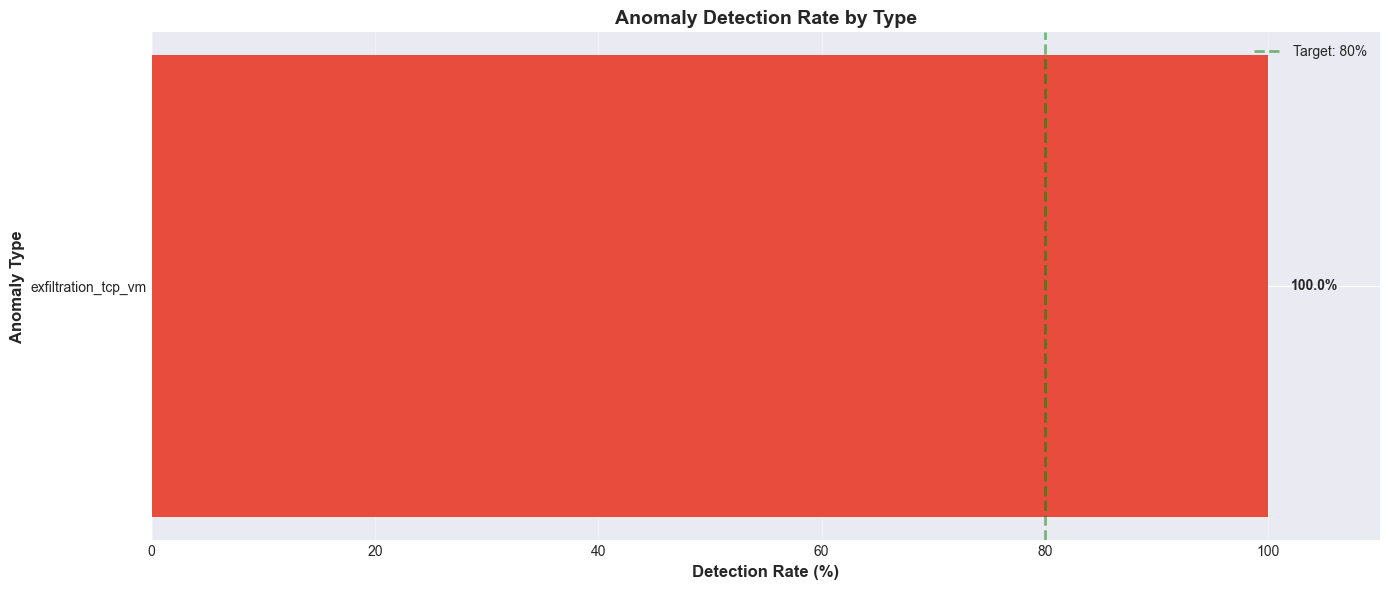

In [32]:
fig, ax = plt.subplots(figsize=(14, 6))

phases = injection_df['Phase'].tolist()
detection_rates = injection_df['Detection Rate (%)'].tolist()

colors = ['#e74c3c' if rate >= 80 else '#f39c12' if rate >= 50 else '#95a5a6' for rate in detection_rates]

bars = ax.barh(phases, detection_rates, color=colors)

for i, (bar, rate) in enumerate(zip(bars, detection_rates)):
    ax.text(rate + 2, i, f'{rate:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Detection Rate (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Anomaly Type', fontsize=12, fontweight='bold')
ax.set_title('Anomaly Detection Rate by Type', fontsize=14, fontweight='bold')
ax.set_xlim(0, 110)
ax.grid(axis='x', alpha=0.3)

ax.axvline(x=80, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Target: 80%')
ax.legend()

plt.tight_layout()
plt.show()

### 6.2 Accuracy Comparison: Baselines vs Injections

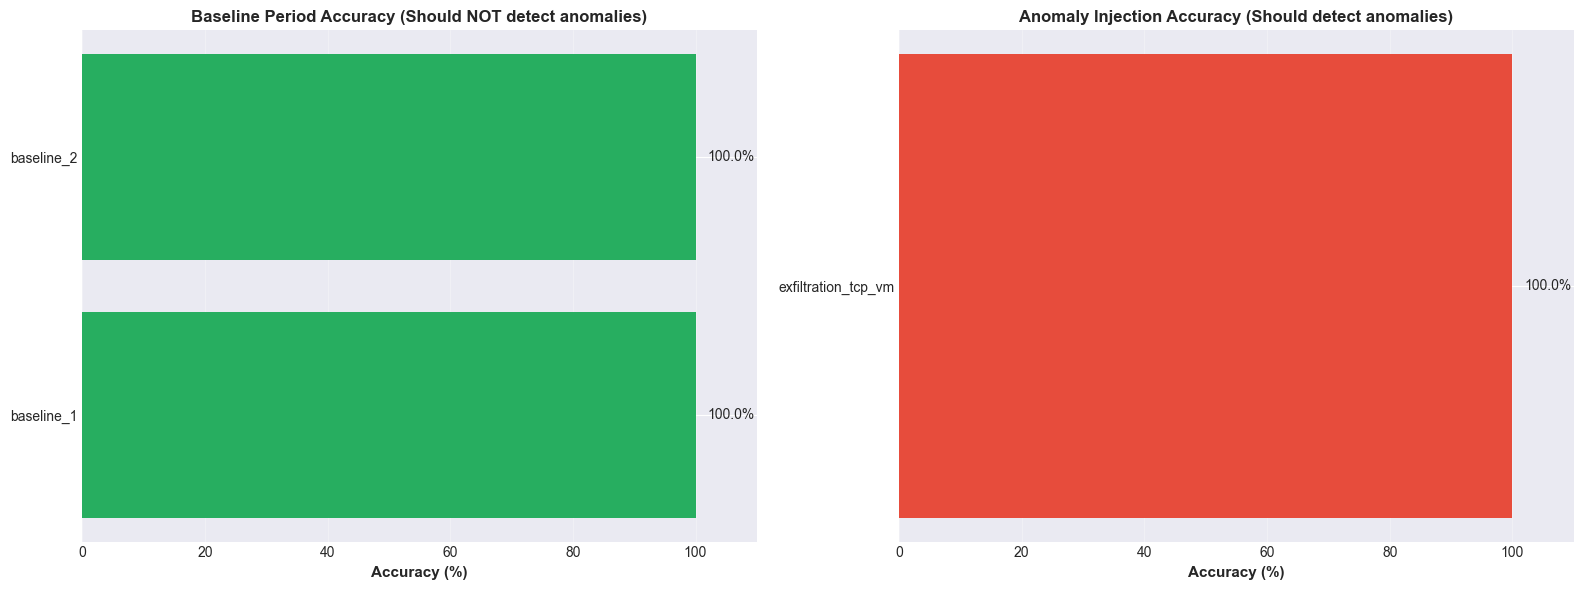

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

baseline_phases = baseline_df['Phase'].tolist()
baseline_acc = baseline_df['Accuracy (%)'].tolist()

bars1 = ax1.barh(baseline_phases, baseline_acc, color='#27ae60')
for i, (bar, acc) in enumerate(zip(bars1, baseline_acc)):
    ax1.text(acc + 2, i, f'{acc:.1f}%', va='center', fontsize=10)

ax1.set_xlabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax1.set_title('Baseline Period Accuracy (Should NOT detect anomalies)', fontsize=12, fontweight='bold')
ax1.set_xlim(0, 110)
ax1.grid(axis='x', alpha=0.3)

injection_phases = injection_df['Phase'].tolist()
injection_acc = injection_df['Accuracy (%)'].tolist()

bars2 = ax2.barh(injection_phases, injection_acc, color='#e74c3c')
for i, (bar, acc) in enumerate(zip(bars2, injection_acc)):
    ax2.text(acc + 2, i, f'{acc:.1f}%', va='center', fontsize=10)

ax2.set_xlabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax2.set_title('Anomaly Injection Accuracy (Should detect anomalies)', fontsize=12, fontweight='bold')
ax2.set_xlim(0, 110)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 6.3 Timeline View: Predictions Over Time

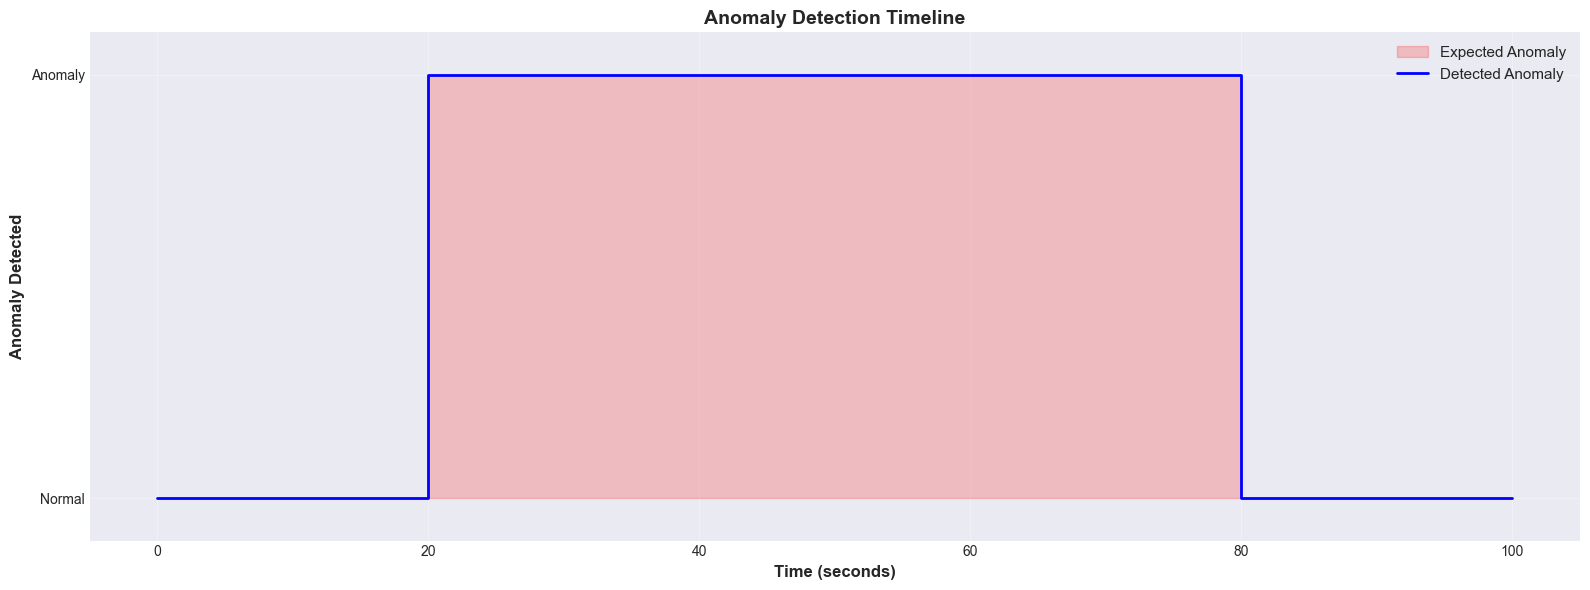

In [34]:
fig, ax = plt.subplots(figsize=(16, 6))

all_timestamps = []
all_predictions = []
all_expected = []

start_time = results[0]['timestamps'][0]

for result in results:
    timestamps = [(t - start_time) for t in result['timestamps']]
    predictions = result['predictions']
    expected = [1 if result['expected'] == 'anomaly' else 0] * len(predictions)
    
    all_timestamps.extend(timestamps)
    all_predictions.extend(predictions)
    all_expected.extend(expected)

ax.fill_between(all_timestamps, 0, all_expected, alpha=0.2, color='red', label='Expected Anomaly', step='post')
ax.plot(all_timestamps, all_predictions, linewidth=2, color='blue', label='Detected Anomaly', drawstyle='steps-post')

ax.set_xlabel('Time (seconds)', fontsize=12, fontweight='bold')
ax.set_ylabel('Anomaly Detected', fontsize=12, fontweight='bold')
ax.set_title('Anomaly Detection Timeline', fontsize=14, fontweight='bold')
ax.set_ylim(-0.1, 1.1)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Normal', 'Anomaly'])
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.4 System Metrics During Test

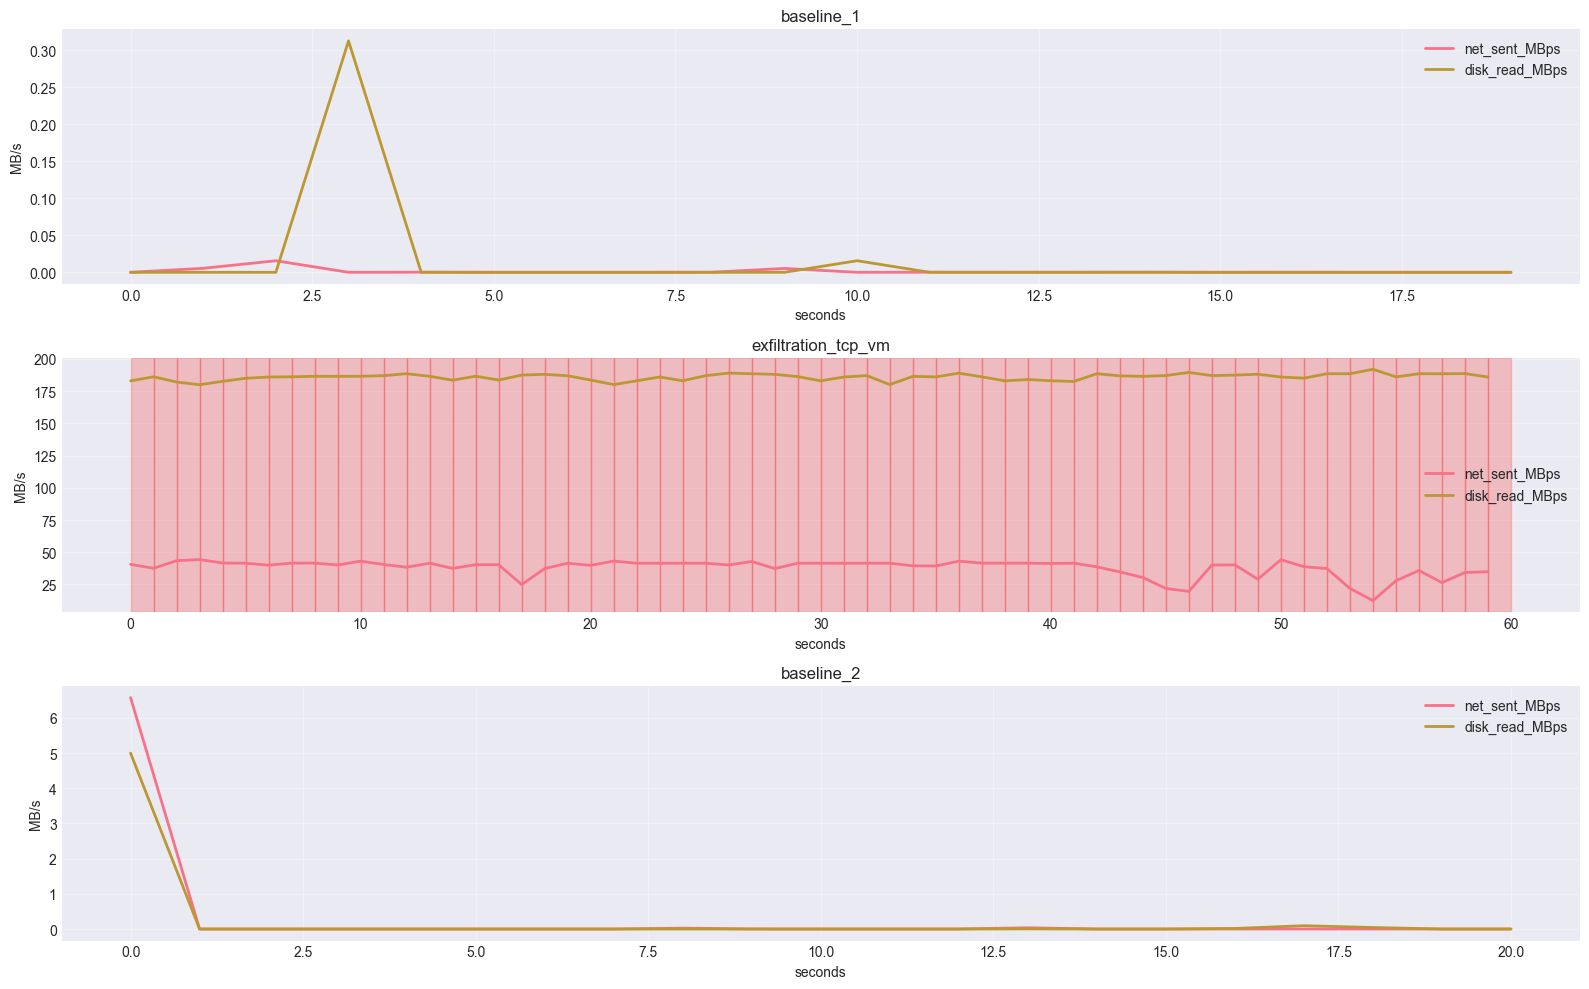

In [35]:
# Plot key signals for baseline vs exfiltration
phases_to_plot = ["baseline_1", "exfiltration_tcp_vm", "baseline_2"]

fig, axes = plt.subplots(3, 1, figsize=(16, 10))

for idx, name in enumerate(phases_to_plot):
    phase_result = next((r for r in results if r["phase"] == name), None)
    if phase_result is None:
        continue

    ax = axes[idx]
    t = list(range(len(phase_result["predictions"])))

    ax.plot(t, phase_result["net_sent_MBps"], linewidth=2, label="net_sent_MBps")
    ax.plot(t, phase_result["disk_read_MBps"], linewidth=2, label="disk_read_MBps")

    # highlight predicted anomalies
    for i, pred in enumerate(phase_result["predictions"]):
        if pred == 1:
            ax.axvspan(i, i + 1, alpha=0.2, color="red")

    ax.set_title(name)
    ax.set_xlabel("seconds")
    ax.set_ylabel("MB/s")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

### 6.5 Confusion Matrix Summary

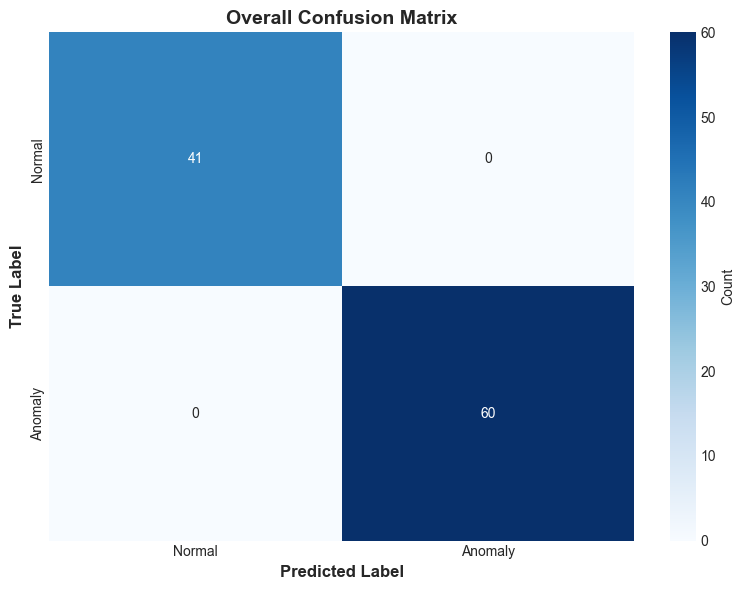


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        41
     Anomaly       1.00      1.00      1.00        60

    accuracy                           1.00       101
   macro avg       1.00      1.00      1.00       101
weighted avg       1.00      1.00      1.00       101



In [36]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for result in results:
    expected_label = 1 if result['expected'] == 'anomaly' else 0
    y_true.extend([expected_label] * len(result['predictions']))
    y_pred.extend(result['predictions'])

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Count'})

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Overall Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n' + '='*80)
print('CLASSIFICATION REPORT')
print('='*80)
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly']))
print('='*80)

## 7. Key Findings Summary

In [37]:
best_detection = injection_df.loc[injection_df['Detection Rate (%)'].idxmax()]
worst_detection = injection_df.loc[injection_df['Detection Rate (%)'].idxmin()]

false_positive_rate = baseline_df['Detection Rate (%)'].mean()

print('\n' + '='*80)
print('KEY FINDINGS')
print('='*80)

print(f'\n🏆 BEST DETECTION:')
print(f"   Type: {best_detection['Phase']}")
print(f"   Detection Rate: {best_detection['Detection Rate (%)']}%")

print(f'\n⚠️  WORST DETECTION:')
print(f"   Type: {worst_detection['Phase']}")
print(f"   Detection Rate: {worst_detection['Detection Rate (%)']}%")

print(f'\n📊 FALSE POSITIVE RATE (Baselines):')
print(f'   Average: {false_positive_rate:.1f}%')
if false_positive_rate < 10:
    print(f'   Status: ✓ Excellent (< 10%)')
elif false_positive_rate < 20:
    print(f'   Status: ⚠️ Acceptable (< 20%)')
else:
    print(f'   Status: ❌ High (> 20%)')

print(f'\n🎯 OVERALL PERFORMANCE:')
print(f'   Baseline Accuracy: {baseline_avg_accuracy:.1f}%')
print(f'   Injection Accuracy: {injection_avg_accuracy:.1f}%')
print(f'   Combined Accuracy: {overall_accuracy:.1f}%')

if overall_accuracy >= 90:
    print(f'   Status: ✓ Excellent performance')
elif overall_accuracy >= 80:
    print(f'   Status: ✓ Good performance')
elif overall_accuracy >= 70:
    print(f'   Status: ⚠️ Acceptable performance')
else:
    print(f'   Status: ❌ Needs improvement')

print('\n' + '='*80)


KEY FINDINGS

🏆 BEST DETECTION:
   Type: exfiltration_tcp_vm
   Detection Rate: 100.0%

⚠️  WORST DETECTION:
   Type: exfiltration_tcp_vm
   Detection Rate: 100.0%

📊 FALSE POSITIVE RATE (Baselines):
   Average: 0.0%
   Status: ✓ Excellent (< 10%)

🎯 OVERALL PERFORMANCE:
   Baseline Accuracy: 100.0%
   Injection Accuracy: 100.0%
   Combined Accuracy: 100.0%
   Status: ✓ Excellent performance

